# Circular Inclusion In A Square

This notebook builds a synthetic conductivity on the square domain $(0, 2) \times (0, 2)$ with a circular inclusion centered at $(1, 1)$. The conductivity is $2$ inside the disk and $1$ outside.

It then runs the square-domain CEM $\rightarrow$ trig-basis $\rightarrow$ inverse pipelines: 
- Born approximation (deep D-bar paper)
- GMRES-based D-bar solve (original D-bar paper).

Note: the forward solver still uses a dense CEM solve, and the D-bar inverse solves a GMRES problem for every reconstruction pixel. To keep the example practical, the forward grid and reconstruction grid are separated via `grid_size` and `recon_image_size`.

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve().parent

from torch_dbar.dbar import DbarReconstruction2D, build_dn_map_from_electrode_data
from torch_dbar.forward_solver import DiffusionEquation2D
from torch_dbar.cem_solver import generate_adjacent_current_patterns, CompleteElectrodeModel

torch.set_default_dtype(torch.float32)

In [21]:
grid_size = 64
recon_image_size = 64
domain_size = 2.0
n_electrodes = 32
n_trig_modes = n_electrodes - 1
basis_type = 'square-harmonic' # 'trig' or 'square-harmonic'
n_boundary_samples = 512
k_grid_size = 73
k_radius = 4.0
contact_impedance = 1.0
gmres_restart = 50
gmres_rtol = 1e-7
gmres_maxiter = 1000

disk_center = (0.5, 1)
disk_radius = 0.15
disk_conductivity = 10.0
background_conductivity = 1.0

In [22]:
eq = DiffusionEquation2D(grid_size=grid_size, domain_size=domain_size, grid_type='node')
bie = CompleteElectrodeModel(eq)

sigma_ref = torch.full((eq.Nx, eq.Ny), background_conductivity, dtype=torch.float64)
sigma_gt = sigma_ref.clone()
mask = (eq.x_nodes - disk_center[0]) ** 2 + (eq.y_nodes - disk_center[1]) ** 2 <= disk_radius ** 2
sigma_gt[mask] = disk_conductivity

current_patterns = generate_adjacent_current_patterns(n_electrodes, dtype=torch.float64)
currents = current_patterns.transpose(0, 1)

_, electrode_voltages_ref = bie.solve_cem(
    sigma_ref,
    currents,
    z_contact=contact_impedance,
    n_electrodes=n_electrodes,
)
_, electrode_voltages_gt = bie.solve_cem(
    sigma_gt,
    currents,
    z_contact=contact_impedance,
    n_electrodes=n_electrodes,
)

dn_ref = build_dn_map_from_electrode_data(
    electrode_voltages_ref.transpose(0, 1),
    current_patterns=current_patterns,
    domain_size=domain_size,
    basis_type=basis_type,
    n_boundary_samples=n_boundary_samples,
)
dn_gt = build_dn_map_from_electrode_data(
    electrode_voltages_gt.transpose(0, 1),
    current_patterns=current_patterns,
    domain_size=domain_size,
    basis_type=basis_type,
    n_boundary_samples=n_boundary_samples,
)

In [23]:
born_reconstructor = DbarReconstruction2D(
    image_size=recon_image_size,
    n_boundary_nodes=n_boundary_samples,
    basis_type=basis_type,
    n_trig_modes=n_trig_modes,
    n_electrodes=n_electrodes,
    k_grid_size=k_grid_size,
    k_radius=k_radius,
    domain_size=domain_size,
    inverse_method='born',
    scattering_scale=2,
)

dbar_reconstructor = DbarReconstruction2D(
    image_size=recon_image_size,
    n_boundary_nodes=n_boundary_samples,
    basis_type=basis_type,
    n_trig_modes=n_trig_modes,
    n_electrodes=n_electrodes,
    k_grid_size=k_grid_size,
    k_radius=k_radius,
    domain_size=domain_size,
    inverse_method='dbar',
    scattering_scale=2,
    gmres_restart=gmres_restart,
    gmres_rtol=gmres_rtol,
    gmres_maxiter=gmres_maxiter,
)

sigma_rec_born = born_reconstructor(lambda_sigma=dn_gt, lambda_ref=dn_ref)[0].detach().cpu()
sigma_rec_dbar = dbar_reconstructor(lambda_sigma=dn_gt, lambda_ref=dn_ref)[0].detach().cpu()
sigma_gt_cpu = sigma_gt.detach().cpu()

print(f'Ground truth range: {float(sigma_gt_cpu.min()):.6f} to {float(sigma_gt_cpu.max()):.6f}')
print(f'Born reconstruction range: {float(sigma_rec_born.min()):.6f} to {float(sigma_rec_born.max()):.6f}')
print(f'D-bar reconstruction range: {float(sigma_rec_dbar.min()):.6f} to {float(sigma_rec_dbar.max()):.6f}')

Ground truth range: 1.000000 to 10.000000
Born reconstruction range: 0.722737 to 1.263640
D-bar reconstruction range: 0.915019 to 1.104276


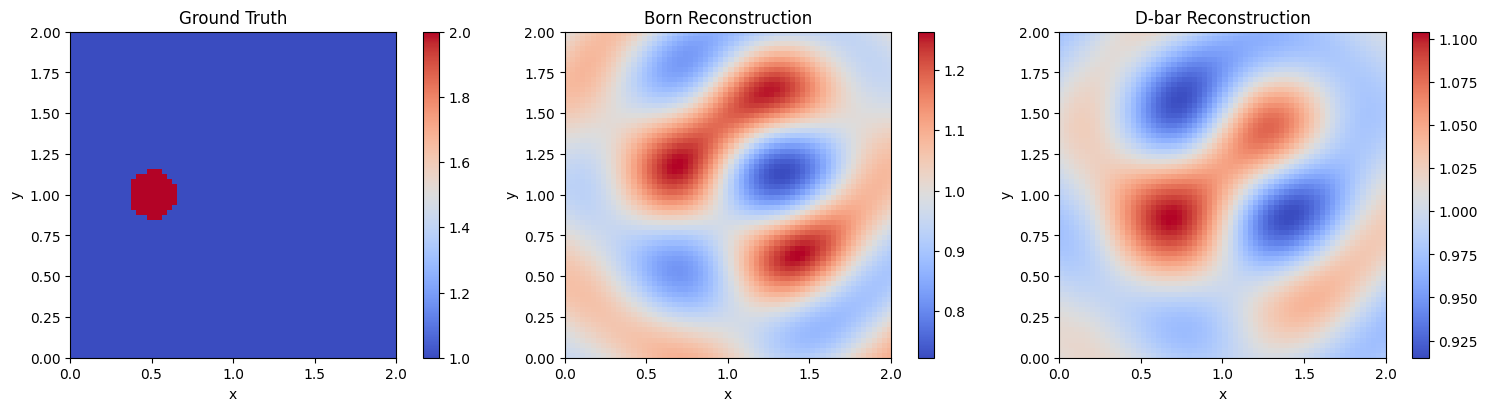

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
extent = (0.0, domain_size, 0.0, domain_size)

im0 = axes[0].imshow(sigma_gt_cpu.T, origin='lower', extent=extent, cmap='coolwarm', vmin=1.0, vmax=2.0)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im1 = axes[1].imshow(sigma_rec_born.T, origin='lower', extent=extent, cmap='coolwarm')
axes[1].set_title('Born Reconstruction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

im2 = axes[2].imshow(sigma_rec_dbar.T, origin='lower', extent=extent, cmap='coolwarm')
axes[2].set_title('D-bar Reconstruction')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()

## Two Random Circular Inclusions

This section samples two non-overlapping circular inclusions with random centers, radii, and conductivities, then runs the same forward and inverse pipeline on two reproducible random examples.

In [20]:
random_seed = 1127
num_examples = 2
minimum_center_distance = 0.9

generator = torch.Generator().manual_seed(random_seed)


def sample_two_inclusions(
    generator,
    *,
    domain_size,
    min_radius=0.10,
    max_radius=0.20,
    min_gap=0.05,
    min_center_distance=minimum_center_distance,
    max_tries=500,
    background=1.0,
    conductivity_range=(4, 10.0),
):
    inclusions = []
    for _ in range(2):
        for _ in range(max_tries):
            radius = min_radius + (max_radius - min_radius) * torch.rand(1, generator=generator).item()
            cx = radius + (domain_size - 2 * radius) * torch.rand(1, generator=generator).item()
            cy = radius + (domain_size - 2 * radius) * torch.rand(1, generator=generator).item()
            conductivity = conductivity_range[0] + (conductivity_range[1] - conductivity_range[0]) * torch.rand(1, generator=generator).item()
            if conductivity >= background:
                conductivity += 0.5
            if all(
                ((cx - inc['center'][0]) ** 2 + (cy - inc['center'][1]) ** 2) ** 0.5
                >= max(radius + inc['radius'] + min_gap, min_center_distance)
                for inc in inclusions
            ):
                inclusions.append(
                    {
                        'center': (cx, cy),
                        'radius': radius,
                        'conductivity': conductivity,
                    }
                )
                break
        else:
            raise RuntimeError('Failed to sample two non-overlapping inclusions.')
    return inclusions


def conductivity_from_inclusions(inclusions):
    sigma = torch.full((eq.Nx, eq.Ny), background_conductivity, dtype=torch.float64)
    for inc in inclusions:
        mask = (eq.x_nodes - inc['center'][0]) ** 2 + (eq.y_nodes - inc['center'][1]) ** 2 <= inc['radius'] ** 2
        sigma[mask] = inc['conductivity']
    return sigma


def reconstruct_sigma(sigma):
    _, electrode_voltages = bie.solve_cem(
        sigma,
        currents,
        z_contact=contact_impedance,
        n_electrodes=n_electrodes,
    )
    dn_sigma = build_dn_map_from_electrode_data(
        electrode_voltages.transpose(0, 1),
        current_patterns=current_patterns,
        domain_size=domain_size,
        basis_type=basis_type,
        n_boundary_samples=n_boundary_samples,
    )
    sigma_rec_born = born_reconstructor(lambda_sigma=dn_sigma, lambda_ref=dn_ref)[0].detach().cpu()
    sigma_rec_dbar = dbar_reconstructor(lambda_sigma=dn_sigma, lambda_ref=dn_ref)[0].detach().cpu()
    return sigma.detach().cpu(), sigma_rec_born, sigma_rec_dbar

In [12]:
examples = []
extent = (0.0, domain_size, 0.0, domain_size)

for example_idx in range(num_examples):
    inclusions = sample_two_inclusions(
        generator,
        domain_size=domain_size,
        background=background_conductivity,
    )
    sigma_random = conductivity_from_inclusions(inclusions)
    sigma_gt_random, sigma_born_random, sigma_dbar_random = reconstruct_sigma(sigma_random)
    examples.append(
        {
            'inclusions': inclusions,
            'sigma_gt': sigma_gt_random,
            'sigma_born': sigma_born_random,
            'sigma_dbar': sigma_dbar_random,
        }
    )

    print(f'Example {example_idx + 1}')
    for inclusion_idx, inclusion in enumerate(inclusions, start=1):
        cx, cy = inclusion['center']
        print(
            f"  Inclusion {inclusion_idx}: center=({cx:.3f}, {cy:.3f}), radius={inclusion['radius']:.3f}, conductivity={inclusion['conductivity']:.3f}"
        )


Example 1
  Inclusion 1: center=(1.700, 1.042), radius=0.140, conductivity=4.681
  Inclusion 2: center=(0.717, 0.451), radius=0.193, conductivity=4.676
Example 2
  Inclusion 1: center=(0.425, 0.258), radius=0.134, conductivity=6.290
  Inclusion 2: center=(0.732, 1.687), radius=0.188, conductivity=6.379


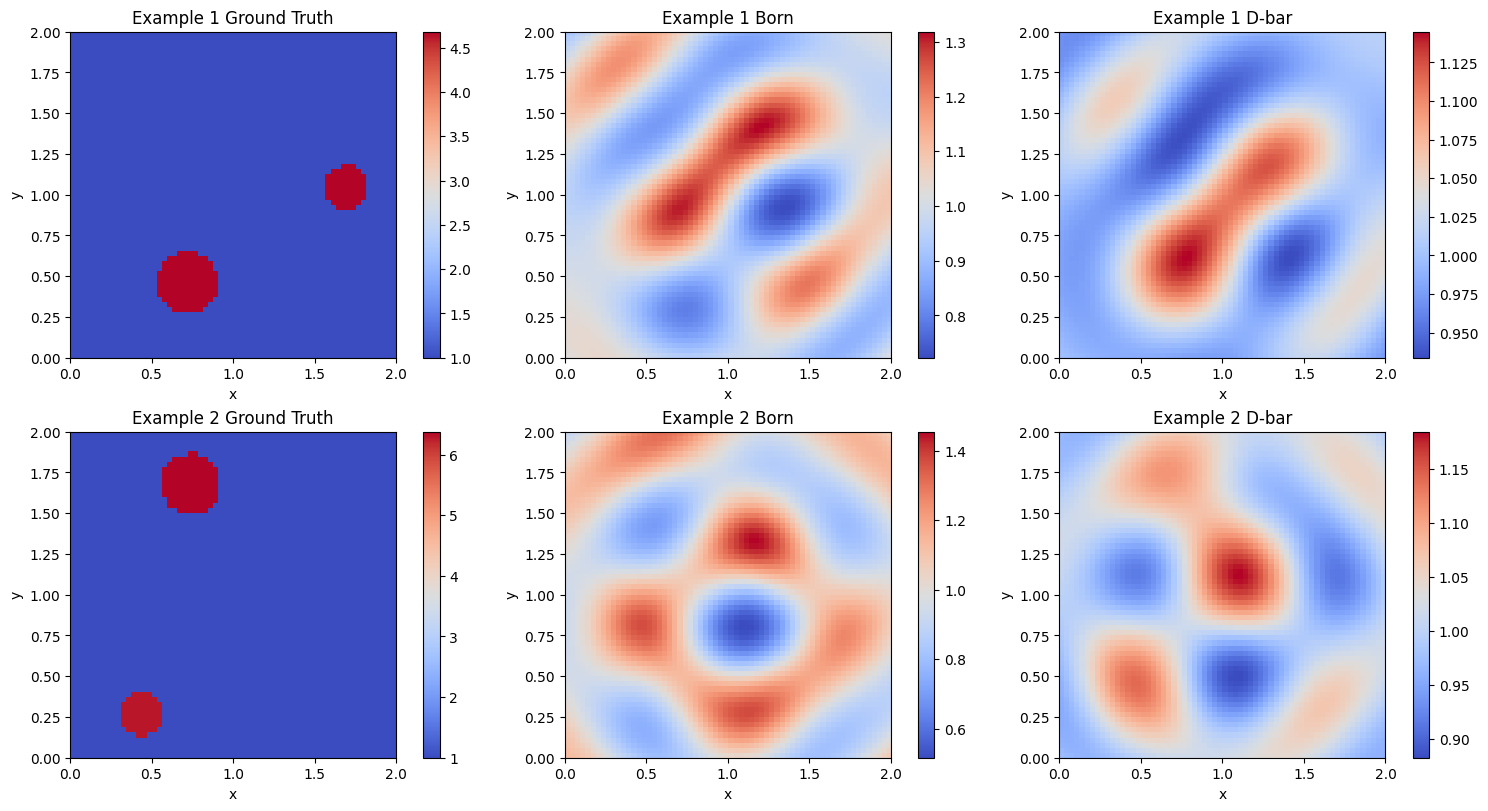

In [13]:
fig, axes = plt.subplots(num_examples, 3, figsize=(15, 4 * num_examples), constrained_layout=True)
if num_examples == 1:
    axes = axes[None, :]

for row, example in enumerate(examples):

    im0 = axes[row, 0].imshow(example['sigma_gt'].T, origin='lower', extent=extent, cmap='coolwarm')
    axes[row, 0].set_title(f'Example {row + 1} Ground Truth')
    axes[row, 0].set_xlabel('x')
    axes[row, 0].set_ylabel('y')

    im1 = axes[row, 1].imshow(example['sigma_born'].T, origin='lower', extent=extent, cmap='coolwarm')
    axes[row, 1].set_title(f'Example {row + 1} Born')
    axes[row, 1].set_xlabel('x')
    axes[row, 1].set_ylabel('y')

    im2 = axes[row, 2].imshow(example['sigma_dbar'].T, origin='lower', extent=extent, cmap='coolwarm')
    axes[row, 2].set_title(f'Example {row + 1} D-bar')
    axes[row, 2].set_xlabel('x')
    axes[row, 2].set_ylabel('y')

    fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)
    fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)
    fig.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

plt.show()